<a href="https://colab.research.google.com/github/jiminmini/mini/blob/ESAA_OB/9_15_%ED%95%84%EC%82%AC%EA%B3%BC%EC%A0%9C_%EC%B5%9C%EC%A2%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**[개념 정리]**

##**[군집]**

- 샘플=하나의 그룹
- 차원 축소 기법, 준지도 학습, 이미지 분할에 이용

##**[k-평균]**
- 데이터셋을 빠르고 효율적으로 클러스터로 묶을 수 있는 간단한 알고리즘

- 샘플의 레이블=알고리즘이 샘플에 할당한 클러스터의 인덱스

- k-평균 알고리즘: 제한된 횟수 안에 수렴하는 것을 보장

##**[군집을 사용한 이미지 분할]**
- 이미지를 세그먼트 여러 개로 분할하는 작업
- 색상 분할: 동일한 색상을 가진 픽셀을 같은 세그먼트에 할당

##**[군집을 사용한 준지도 학습]**
- 레이블이 없는 데이터가 많고 레이블이 있는 데이터는 적을 때 사용

#**[코드 필사]**

In [2]:
# 데이터 불러오기

from sklearn.datasets import make_blobs
import numpy as np

# make_blobs()의 정확한 인수는 중요하지 않습니다.
blob_centers = np.array([[ 0.2, 2.3], [-1.5 , 2.3], [-2.8, 1.8], [-2.8, 2.8], [-2.8, 1.3]])

blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

x, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,random_state=7)

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

k = 5
X, _ = make_blobs(n_samples=1500, centers=k, random_state=42)  # (X, y) 반환
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

In [4]:
y_pred

array([4, 0, 2, ..., 4, 0, 1], dtype=int32)

In [5]:
y_pred is kmeans.labels_

True

In [6]:
kmeans.cluster_centers_

array([[ 2.07564643,  4.16862733],
       [-6.85406294, -6.7780619 ],
       [-8.90992726,  7.38564553],
       [-2.51326868,  8.99855257],
       [ 4.7933247 ,  1.99328561]])

In [7]:
import numpy as np
x_new=np.array([[0,2],[3,2],[-3,3],[-3,2.5]])
kmeans.predict(x_new)

array([0, 4, 0, 0], dtype=int32)

In [8]:
kmeans.transform(x_new)

array([[ 3.00187485, 11.13699014, 10.41114699,  7.43614534,  4.79332941],
       [ 2.35740833, 13.19685292, 13.07101928,  8.90931365,  1.79333727],
       [ 5.20844281, 10.5101996 ,  7.35942436,  6.01826722,  7.85807762],
       [ 5.34289283, 10.04670263,  7.66790535,  6.51675478,  7.80978037]])

In [9]:
good_init=np.array([[-3,3],[-3,2],[-3,1],[-1,2],[0,2]])
kmeans=KMeans(n_clusters=5, init=good_init, n_init=1)

In [10]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 데이터 생성
x, _ = make_blobs(n_samples=1500, centers=5, random_state=42)

# 모델 학습
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(x)

KMeans(n_clusters=5, random_state=42)

In [11]:
kmeans.fit_predict(x)
kmeans.inertia_

2845.0221266366993

In [12]:
kmeans.score(x)

-2845.0221266366993

In [13]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans =MiniBatchKMeans(n_clusters=5)
minibatch_kmeans.fit(x)

MiniBatchKMeans(n_clusters=5)

In [14]:
from sklearn.metrics import silhouette_score
silhouette_score(x,kmeans.labels_)

np.float64(0.6726526016700117)

In [15]:
from google.colab import files
uploaded = files.upload()

Saving ladybug.png to ladybug.png


In [50]:
import matplotlib.pyplot as plt
from matplotlib.image import imread
image = plt.imread("ladybug.png")
image.shape

(533, 800, 3)

In [18]:
x=image.reshape(-1,3)
kmeans=KMeans(n_clusters=8).fit(x)
segmented_img=kmeans.cluster_centers_[kmeans.labels_]
segmented_img=segmented_img.reshape(image.shape)

In [20]:
from sklearn.datasets import load_digits

digits = load_digits()
x = digits.data
y = digits.target

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y)

In [22]:
from sklearn.linear_model import LogisticRegression
log_reg=LogisticRegression()
log_reg.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [23]:
log_reg.score(x_test,y_test)

0.9622222222222222

In [24]:
from sklearn.pipeline import Pipeline
pipeline=Pipeline([
    ("kmeans", KMeans(n_clusters=50)),
    ("log_reg", LogisticRegression()),
])
pipeline.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                ('log_reg', LogisticRegression())])

In [25]:
pipeline.score(x_test,y_test)

0.9688888888888889

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = dict(kmeans__n_clusters=range(2, 100))

grid_clf = GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(x_train, y_train)


Fitting 3 folds for each of 98 candidates, totalling 294 fits
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=4; total time=   0.1s


...

[CV] END ..............................kmeans__n_clusters=99; total time=   2.8s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END ..............................kmeans__n_clusters=99; total time=   1.9s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                                       ('log_reg', LogisticRegression())]),
             param_grid={'kmeans__n_clusters': range(2, 100)}, verbose=2)

In [27]:
grid_clf.best_params_

{'kmeans__n_clusters': 98}

In [28]:
grid_clf.score(x_test,y_test)

0.9644444444444444

In [29]:
n_labeled=50
log_reg=LogisticRegression()
log_reg.fit(x_train[:n_labeled], y_train[:n_labeled])

LogisticRegression()

In [30]:
log_reg.score(x_test,y_test)

0.8444444444444444

In [31]:
k=50
kmeans=KMeans(n_clusters=k)
x_digits_dist=kmeans.fit_transform(x_train)
representative_digit_idx=np.argmin(x_digits_dist,axis=0)
x_representative_digits=x_train[representative_digit_idx]

In [51]:
y_representative_digits=np.array([4,8,0,6,8,3,7,7,9,2,5,5,8,5,2,1,2,3,6,1,1,6,9,0,8,3,0,7,4,1,6,5,2,4,1,8,6,3,9,2,4,2,9,4,7,6,2,3,1,1])

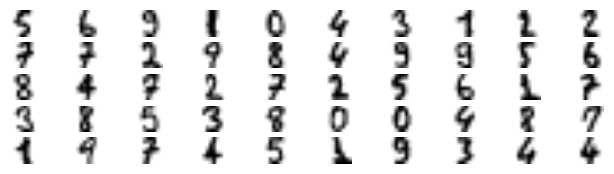

In [54]:
plt.figure(figsize=(8, 2))

for index, x_representative_digit in enumerate(x_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(x_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

plt.show()

In [33]:
log_reg=LogisticRegression()
log_reg.fit(x_representative_digits,y_representative_digits)
log_reg.score(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.06888888888888889

In [34]:
y_train_propagated=np.empty(len(x_train),dtype=np.int32)
for i in range(k):
    y_train_propagated[kmeans.labels_==i]=y_representative_digits[i]

In [35]:
log_reg=LogisticRegression()
log_reg.fit(x_train,y_train_propagated)
log_reg.score(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.06222222222222222

In [36]:
percentile_closet=20

x_cluster_dist=x_digits_dist[np.arange(len(x_train)),kmeans.labels_]
for i in range(k):
    in_cluster=(kmeans.labels_==i)
    cluster_dist=x_cluster_dist[in_cluster]
    cutoff_distance=np.percentile(cluster_dist,percentile_closet)
    above_cutoff=(x_cluster_dist> cutoff_distance)
    x_cluster_dist[in_cluster&above_cutoff]=-1
partially_propagated=(x_cluster_dist !=-1)
x_train_partially_propagate=x_train[partially_propagated]
y_train_partially_propagated=y_train_propagated[partially_propagated]

In [37]:
log_reg=LogisticRegression()
log_reg.fit(x_train_partially_propagate, y_train_partially_propagated)
log_reg.score(x_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.08222222222222222

In [38]:
np.mean(y_train_partially_propagated==y_train[partially_propagated])

np.float64(0.056140350877192984)

In [39]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

x,y=make_moons(n_samples=1000, noise=0.05)
dbscan=DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(x)

DBSCAN(eps=0.05)

In [40]:
dbscan.labels_

array([ 0,  1,  2,  3,  4,  3,  5,  6,  7, -1,  4,  5,  0,  3,  0,  7,  5,
        0,  3,  3, -1,  8,  9,  7,  9, -1,  4,  3,  3,  0,  9,  4,  0,  9,
        0,  0,  0,  4,  8,  0, -1,  0, -1,  8, -1,  0,  8,  0,  0,  0,  0,
        0,  0,  7,  7,  3,  6,  0,  4,  3, -1,  4,  0,  3,  5, -1, -1,  0,
        3,  2,  4,  0,  4, -1,  0,  0,  0,  9,  2,  3,  4,  6,  0,  3,  0,
        5, 10,  3,  4, 10, -1,  3,  2,  3,  3, -1,  8,  0,  5,  0,  9,  9,
        7,  2,  6,  4, 11,  0,  3,  4,  9,  0,  6,  5, -1,  7,  3,  8, -1,
       11,  8,  7,  0,  8,  0,  0,  0,  8,  7,  0,  0,  3,  8,  3,  6,  3,
        3,  5,  0,  3,  3,  9,  5,  2,  7,  6,  0,  7,  4,  9,  8,  4,  6,
        0,  0,  4,  0,  3,  0,  3,  7,  3,  0,  8,  8, 10, -1,  3,  7, -1,
        4,  9,  5,  7,  8,  9,  3,  5,  5,  0,  3, -1,  5,  4,  5,  3,  8,
        0,  7,  8,  0,  5,  0,  4,  8,  4,  5,  9, -1,  0,  0, -1,  4,  0,
        0,  4,  5,  6,  0,  5,  0,  3,  1,  6,  0,  0,  6,  8,  3,  2,  5,
        3,  1,  4, -1,  1

In [41]:
len(dbscan.core_sample_indices_)

803

In [42]:
dbscan.core_sample_indices_

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  21,  22,  23,  24,  26,  27,  29,  30,
        31,  32,  33,  34,  35,  36,  37,  38,  39,  41,  43,  45,  46,
        47,  48,  49,  51,  52,  53,  54,  56,  57,  58,  59,  62,  63,
        64,  67,  68,  70,  71,  72,  74,  76,  77,  78,  79,  80,  82,
        83,  84,  85,  86,  89,  91,  92,  93,  94,  96,  97,  98, 100,
       102, 104, 105, 106, 107, 108, 110, 111, 112, 115, 116, 117, 121,
       122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 134, 135,
       136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148,
       149, 150, 152, 153, 154, 155, 156, 157, 158, 162, 163, 164, 165,
       167, 168, 170, 171, 172, 173, 174, 176, 177, 178, 179, 180, 182,
       183, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196,
       197, 199, 200, 202, 203, 204, 205, 206, 207, 210, 211, 213, 214,
       215, 216, 217, 218, 219, 220, 221, 222, 223, 225, 226, 22

In [43]:
dbscan.components_

array([[ 0.19392507, -0.13941583],
       [ 0.52633575,  0.78253705],
       [-1.04033129, -0.0052433 ],
       ...,
       [-0.63143854,  0.68933733],
       [ 1.02459273,  0.03044649],
       [ 0.96741674,  0.33589543]])

In [44]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [45]:
x_new=np.array([[-0.5,0],[0,0.5],[1,-0.1],[2,1]])
knn.predict(x_new)

array([ 2,  0, 10,  7])

In [46]:
knn.predict_proba(x_new)

array([[0.22, 0.  , 0.4 , 0.  , 0.  , 0.38, 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  ],
       [1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  ],
       [0.14, 0.  , 0.  , 0.02, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.84,
        0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 1.  , 0.  , 0.  , 0.  ,
        0.  , 0.  ]])

In [47]:
y_dist,y_pred_idx=knn.kneighbors(x_new,n_neighbors=1)
y_pred=dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist>0.2]=-1
y_pred.ravel()

array([-1,  0, 10, -1])